<a href="https://colab.research.google.com/github/aiman0642/saas-retention-intelligence/blob/main/10_revenue_at_risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Module 10 — Revenue at Risk

**Project:** SaaS Customer Retention Intelligence System

**Goal of this notebook:** Module 8 produced a churn *probability* per
account. This notebook turns that into a **dollar figure** — the metric
a business stakeholder actually cares about, not a probability score.
The core idea: an account with 90% churn risk but $20/month revenue
matters far less to the business than one with 40% risk and $2,000/month
— dollar exposure and churn probability are not the same ranking, and
this notebook makes that distinction explicit rather than assuming
"highest risk % = highest priority."

**Assumes:** Module 8 has been run (needs `account_risk_scores.csv`).

## 10.1 Mount Google Drive & Load Risk Scores + Revenue Data

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

PROJECT_DIR = "/content/drive/MyDrive/saas-retention-intelligence"
PROCESSED_DIR = f"{PROJECT_DIR}/data/processed"

risk_scores = pd.read_csv(f"{PROCESSED_DIR}/account_risk_scores.csv")
account_view = pd.read_csv(f"{PROCESSED_DIR}/account_view_engineered.csv")

print(f"risk_scores: {risk_scores.shape}")
print(f"account_view: {account_view.shape}")

risk_scores: (500, 4)
account_view: (500, 39)


## 10.2 Merge Risk Scores with Revenue Data

`account_risk_scores.csv` only has the churn probability; MRR/ARR live
in `account_view_engineered.csv` — bring them together into one table.

In [3]:
revenue_cols = ["account_id", "plan_tier", "industry", "mrr_amount", "arr_amount", "billing_frequency"]
revenue_risk = risk_scores.merge(account_view[revenue_cols], on="account_id", how="left")

print(f"revenue_risk shape: {revenue_risk.shape}")
print(f"Missing MRR after merge: {revenue_risk['mrr_amount'].isnull().sum()}")
revenue_risk.head(3)

revenue_risk shape: (500, 9)
Missing MRR after merge: 0


,account_id,churn_flag,churn_probability,risk_level,plan_tier,industry,mrr_amount,arr_amount,billing_frequency
0,A-2e4581,False,0.336580,Medium,Basic,EdTech,836,10032,monthly
1,A-43a9e3,True,0.443463,Medium,Basic,FinTech,882,10584,monthly
2,A-0a282f,False,0.656807,Medium,Basic,DevTools,98,1176,annual


## 10.3 Compute Expected Revenue at Risk

`Expected Revenue at Risk = Monthly Recurring Revenue × Churn Probability`
— a probability-weighted exposure figure, not "this account will
definitely churn and cost this much." A $500/mo account at 40% risk
contributes $200 of expected exposure; a $500/mo account at 90% risk
contributes $450.

In [4]:
revenue_risk["expected_mrr_at_risk"] = revenue_risk["mrr_amount"] * revenue_risk["churn_probability"]
revenue_risk["expected_arr_at_risk"] = revenue_risk["arr_amount"] * revenue_risk["churn_probability"]

print(revenue_risk[["account_id", "mrr_amount", "churn_probability", "expected_mrr_at_risk"]].head(10))

  account_id  mrr_amount  churn_probability  expected_mrr_at_risk
0   A-2e4581         836           0.336580            281.381247
1   A-43a9e3         882           0.443463            391.134272
2   A-0a282f          98           0.656807             64.367110
3   A-1f0ac7        1176           0.324267            381.338060
4   A-ce550d       21691           0.794607          17235.812527
5   A-1b9609           0           0.378717              0.000000
6   A-a0ca4e        5174           0.445952           2307.354686
7   A-e5d6ab        1568           0.270939            424.831640
8   A-7dacce           0           0.436473              0.000000
9   A-10b8da        1666           0.302459            503.896996


## 10.4 Aggregate Revenue at Risk

The headline dashboard number, plus a breakdown by risk tier — this is
what Module 13's Page 1 (Overview) will display as a KPI card.

In [5]:
total_mrr = revenue_risk["mrr_amount"].sum()
total_mrr_at_risk = revenue_risk["expected_mrr_at_risk"].sum()
total_arr_at_risk = revenue_risk["expected_arr_at_risk"].sum()

print(f"Total MRR across all accounts:        ${total_mrr:,.0f}")
print(f"Estimated Monthly Revenue at Risk:    ${total_mrr_at_risk:,.0f}  ({total_mrr_at_risk/total_mrr:.1%} of total MRR)")
print(f"Estimated Annual Revenue at Risk:     ${total_arr_at_risk:,.0f}")

Total MRR across all accounts:        $1,218,555
Estimated Monthly Revenue at Risk:    $522,747  (42.9% of total MRR)
Estimated Annual Revenue at Risk:     $6,272,958


            accounts  total_mrr  expected_mrr_at_risk
risk_level                                           
Low              107     348484          69725.734777
Medium           335     742721         353401.819540
High              58     127350          99618.974204


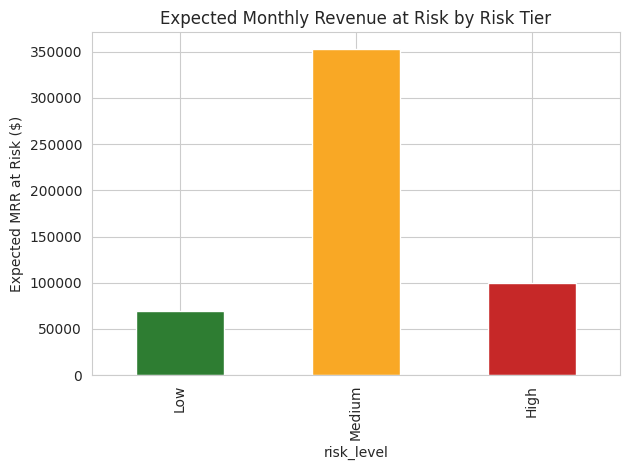

In [6]:
risk_by_tier = revenue_risk.groupby("risk_level").agg(
    accounts=("account_id", "count"),
    total_mrr=("mrr_amount", "sum"),
    expected_mrr_at_risk=("expected_mrr_at_risk", "sum"),
).reindex(["Low", "Medium", "High"])

print(risk_by_tier)

ax = risk_by_tier["expected_mrr_at_risk"].plot(kind="bar", color=["#2E7D32", "#F9A825", "#C62828"])
ax.set_ylabel("Expected MRR at Risk ($)")
ax.set_title("Expected Monthly Revenue at Risk by Risk Tier")
plt.tight_layout()
plt.show()

## 10.5 Revenue at Risk by Plan Tier & Industry

Where is the dollar exposure actually concentrated? This can differ from
where *accounts* are concentrated — a plan tier with fewer but larger
accounts can carry more dollar risk than one with many small accounts.

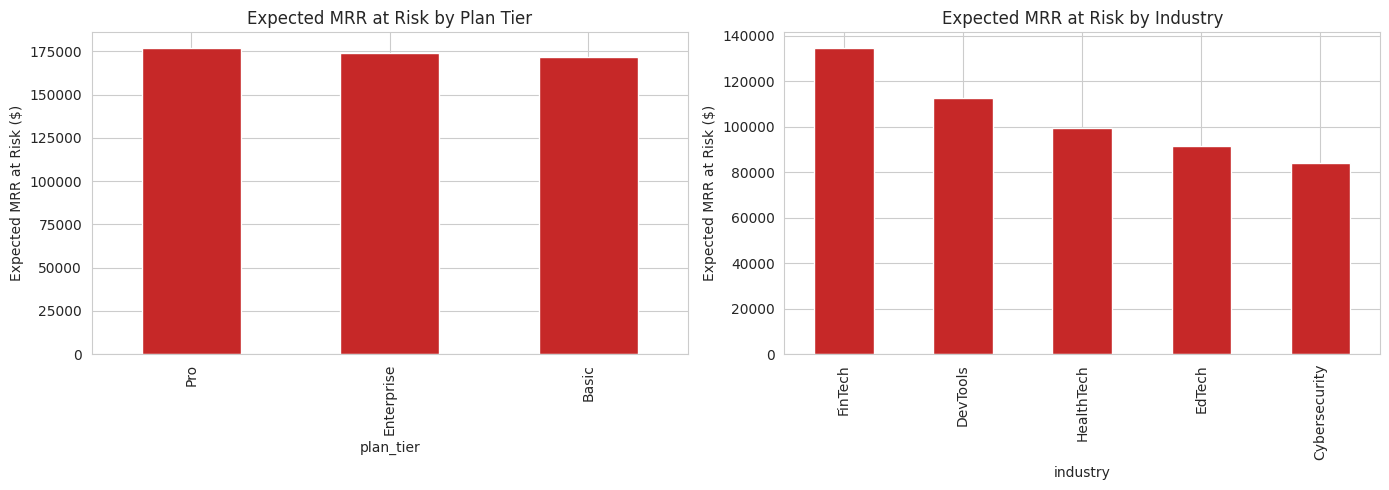

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

revenue_risk.groupby("plan_tier")["expected_mrr_at_risk"].sum().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="#C62828"
)
axes[0].set_title("Expected MRR at Risk by Plan Tier")
axes[0].set_ylabel("Expected MRR at Risk ($)")

revenue_risk.groupby("industry")["expected_mrr_at_risk"].sum().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="#C62828"
)
axes[1].set_title("Expected MRR at Risk by Industry")
axes[1].set_ylabel("Expected MRR at Risk ($)")

plt.tight_layout()
plt.show()

## 10.6 Highest Dollar Exposure ≠ Highest Risk Probability

This is the key business insight this notebook exists to surface. Sort
by **dollar exposure**, not probability — a retention team with limited
capacity should generally prioritize this list, not a plain "highest
risk %" list, since it accounts for how much is actually at stake.

In [8]:
active_accounts = revenue_risk[revenue_risk["churn_flag"] == False].copy()

top_by_dollars = active_accounts.sort_values("expected_mrr_at_risk", ascending=False).head(10)
top_by_probability = active_accounts.sort_values("churn_probability", ascending=False).head(10)

print("Top 10 by DOLLAR exposure (prioritize these for retention outreach):")
print(top_by_dollars[["account_id", "plan_tier", "mrr_amount", "churn_probability", "expected_mrr_at_risk"]].to_string(index=False))

print("\nTop 10 by RAW PROBABILITY (for comparison — notice this is a different list):")
print(top_by_probability[["account_id", "plan_tier", "mrr_amount", "churn_probability", "expected_mrr_at_risk"]].to_string(index=False))

overlap = set(top_by_dollars["account_id"]) & set(top_by_probability["account_id"])
print(f"\nAccounts appearing in BOTH top-10 lists: {len(overlap)} / 10")

Top 10 by DOLLAR exposure (prioritize these for retention outreach):
account_id  plan_tier  mrr_amount  churn_probability  expected_mrr_at_risk
  A-d4e0d4      Basic       23283           0.464800          10821.936998
  A-d792a6 Enterprise       12935           0.816664          10563.551743
  A-0651a4        Pro       12935           0.628865           8134.364401
  A-5c046d      Basic       18507           0.409374           7576.286252
  A-c58f49 Enterprise       13930           0.502755           7003.380821
  A-afa505      Basic       13930           0.454129           6326.019516
  A-c37601      Basic       10746           0.567239           6095.550093
  A-9badbd Enterprise       11741           0.517675           6078.025782
  A-09316c Enterprise       13930           0.423570           5900.335446
  A-e7a1e2 Enterprise        8756           0.617461           5406.489103

Top 10 by RAW PROBABILITY (for comparison — notice this is a different list):
account_id  plan_tier  mrr_

## 10.7 Revenue at Risk — Key Findings

Based on the actual outputs above:

- **Headline number:** an estimated **$522,747/month (42.9% of total
  MRR)** is at risk, against $1,218,555 total MRR — annualized, ~$6.27M.
- **Important calibration caveat, stated plainly:** the model's average
  predicted churn probability across all accounts is **45.8%**, more
  than double the actual observed churn rate of 22%. This is consistent
  with Module 7's finding that Logistic Regression has modest precision
  (34.8%) — it over-flags risk broadly rather than sharply separating
  likely churners from safe accounts. **The $522K figure should be read
  as a relative risk-weighted ranking tool for prioritizing retention
  effort, not a literal forecast of dollars that will actually be
  lost** — that distinction belongs in the README, not just this
  notebook, so the number isn't taken at face value.
- **Concentration by tier:** Medium-risk accounts carry the largest
  share of dollar exposure ($353,402) simply because there are far more
  of them (335 accounts) than High-risk ones (58 accounts, $99,619) —
  a reminder that risk *tier* and dollar *exposure* don't move together
  in a simple way.
- **Concentration by industry:** fairly evenly spread — FinTech highest
  at ~$135K, Cybersecurity lowest at ~$84K, no single industry
  dominates exposure.
- **Dollar exposure vs. probability overlap — the core finding:** only
  **1 of the top 10** accounts by dollar exposure also appears in the
  top 10 by raw probability. Prioritizing outreach by "highest risk %"
  alone would miss nearly the entire set of accounts actually carrying
  the most revenue at stake. This is the concrete business case for why
  this module — and the dashboard's dollar-based sorting — exists at
  all, not just a probability leaderboard.

## 10.8 Save Revenue at Risk Table

For Module 12 (Recommendation Layer) and Module 13's dashboard
(Overview KPIs and Customer Risk lookup pages).

In [9]:
revenue_risk.to_csv(f"{PROCESSED_DIR}/account_revenue_risk.csv", index=False)

summary_metrics = pd.DataFrame([{
    "total_accounts": len(revenue_risk),
    "total_mrr": total_mrr,
    "estimated_mrr_at_risk": total_mrr_at_risk,
    "estimated_arr_at_risk": total_arr_at_risk,
    "pct_mrr_at_risk": total_mrr_at_risk / total_mrr,
}])
summary_metrics.to_csv(f"{PROCESSED_DIR}/revenue_risk_summary.csv", index=False)

print(f"Saved account_revenue_risk.csv and revenue_risk_summary.csv to {PROCESSED_DIR}")

Saved account_revenue_risk.csv and revenue_risk_summary.csv to /content/drive/MyDrive/saas-retention-intelligence/data/processed


## 10.9 Module 10 Summary

- Merged Module 8's churn probabilities with account-level MRR/ARR
- Computed Expected Revenue at Risk per account, totaling **$522,747/mo
  (42.9% of MRR)** — flagged with an explicit calibration caveat, since
  the model's average predicted probability (45.8%) runs well above the
  actual churn rate (22%), meaning this figure is a risk-weighted
  ranking tool, not a literal forecast
- Broke down exposure by risk tier, plan tier, and industry
- **Core finding:** only 1 of the top 10 accounts by dollar exposure
  also appears in the top 10 by raw churn probability — concrete
  evidence that a probability-only priority list would miss most of the
  revenue actually at stake
- Saved `account_revenue_risk.csv` and a summary KPI file for the
  dashboard

**Next:** Module 11 — Customer Segmentation (optional)